# ENSP355 – AI in Cyber Security Lab
## Lab 2: Login Activity Classification and Clustering

**Objective:** Clean a small login-activity dataset, train a Decision Tree to classify **Normal/Suspicious** activity, apply **K-Means clustering**, interpret the results, and test three new login records.

> **Dataset required:** `simple_login_activity.csv`

This notebook follows the supplied lab manual for Q1–Q6. It uses only the four specified input features:
- `failed_logins`
- `login_hour`
- `new_device`
- `download_mb`

Target label: `label` (`Normal` / `Suspicious`)


## Q1. Dataset Inspection and Cleaning — 5 Marks

**Aim:** Identify input columns and target label, remove duplicates, and replace missing numeric values.

**Procedure**
1. Load the CSV file.
2. Display the first rows and dataset information.
3. Count missing values and duplicate rows.
4. Remove duplicates.
5. Fill missing numeric values with the column median.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('simple_login_activity.csv')

print("First five rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values before cleaning:")
print(df.isna().sum())

print("\nDuplicate rows before cleaning:", df.duplicated().sum())
print("Rows before cleaning:", len(df))

First five rows:


,record_id,failed_logins,login_hour,new_device,download_mb,label
0,1,4.0,1,0,164.9,Suspicious
1,2,3.0,3,1,250.6,Suspicious
2,3,3.0,10,0,145.1,Normal
3,4,2.0,11,0,397.8,Normal
4,5,1.0,3,0,409.3,Normal



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   record_id      101 non-null    int64  
 1   failed_logins  100 non-null    float64
 2   login_hour     101 non-null    int64  
 3   new_device     101 non-null    int64  
 4   download_mb    100 non-null    float64
 5   label          101 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 4.9+ KB

Missing values before cleaning:
record_id        0
failed_logins    1
login_hour       0
new_device       0
download_mb      1
label            0
dtype: int64

Duplicate rows before cleaning: 1
Rows before cleaning: 101
Missing values after cleaning:
record_id        0
failed_logins    0
login_hour       0
new_device       0
download_mb      0
label            0
dtype: int64

Total missing values after cleaning: 0
Duplicate rows after cleaning: 0
Final ro

,record_id,failed_logins,login_hour,new_device,download_mb,label
0,1,4.0,1,0,164.9,Suspicious
1,2,3.0,3,1,250.6,Suspicious
2,3,3.0,10,0,145.1,Normal
3,4,2.0,11,0,397.8,Normal
4,5,1.0,3,0,409.3,Normal


In [4]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Fill missing numeric values with the column median
df['failed_logins'] = df['failed_logins'].fillna(
    df['failed_logins'].median()
)

df['download_mb'] = df['download_mb'].fillna(
    df['download_mb'].median()
)

print("Missing values after cleaning:")
print(df.isna().sum())

print("\nTotal missing values after cleaning:", df.isna().sum().sum())
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Final rows:", len(df))

print("\nCleaned first five rows:")
display(df.head())


Missing values after cleaning:
record_id        0
failed_logins    0
login_hour       0
new_device       0
download_mb      0
label            0
dtype: int64

Total missing values after cleaning: 0
Duplicate rows after cleaning: 0
Final rows: 100

Cleaned first five rows:


,record_id,failed_logins,login_hour,new_device,download_mb,label
0,1,4.0,1,0,164.9,Suspicious
1,2,3.0,3,1,250.6,Suspicious
2,3,3.0,10,0,145.1,Normal
3,4,2.0,11,0,397.8,Normal
4,5,1.0,3,0,409.3,Normal


### Q1 Lab Record

- **Input features:** `failed_logins`, `login_hour`, `new_device`, `download_mb`
- **Target label:** `label`
- Missing numeric values are replaced using the **median**.
- Duplicate rows are removed because duplicates can distort analysis and evaluation.

**Why median?** The median is a robust replacement for missing numeric values and is less affected by extreme values than the mean.


## Q2. Training and Testing Split — 5 Marks

**Aim:** Separate the features and label and create training/testing sets.

A **75% training / 25% testing** split is used with `random_state=42` and stratification so that the class proportions are kept similar in both subsets.


In [5]:
from sklearn.model_selection import train_test_split

features = [
    'failed_logins',
    'login_hour',
    'new_device',
    'download_mb'
]

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


Training rows: 75
Testing rows: 25

Training class distribution:
label
Normal        56
Suspicious    19
Name: count, dtype: int64

Testing class distribution:
label
Normal        19
Suspicious     6
Name: count, dtype: int64


### Q2 Lab Record

Testing on the training data is misleading because the model has already learned from those records, so the measured performance may not represent how well it works on unseen login activity.


## Q3. Decision Tree Training and Evaluation — 10 Marks

**Aim:** Train a Decision Tree and interpret accuracy and the confusion matrix.

A shallow tree with `max_depth=4` is used to improve readability and reduce overfitting.


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Normal', 'Suspicious']
)

print("\nConfusion Matrix [Normal, Suspicious]:")
print(cm)


Accuracy: 88.00%

Confusion Matrix [Normal, Suspicious]:
[[19  0]
 [ 3  3]]


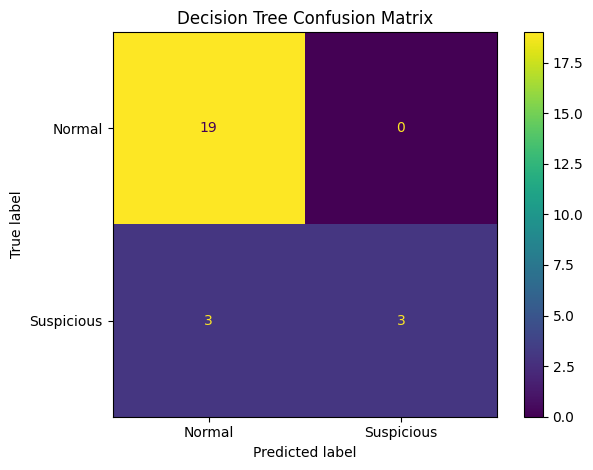

In [7]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=['Normal', 'Suspicious']
)

plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()


### Q3 Interpretation

The confusion matrix separates correct classifications from errors.

- **False positive:** Normal activity incorrectly classified as Suspicious.
- **False negative:** Suspicious activity incorrectly classified as Normal.
- Accuracy below 100% can be realistic because login behaviour can overlap between legitimate and suspicious activity, and a small dataset cannot represent every real-world situation.


## Q4. K-Means Clustering — 10 Marks

**Aim:** Apply an unsupervised learning method and compare the resulting clusters with the known labels.

K-Means does **not** use the `Normal/Suspicious` label while forming clusters. The four numeric features are standardized first because they use different scales.


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('cluster')[features].mean().round(2)
label_summary = pd.crosstab(df['cluster'], df['label'])

print("Cluster mean feature values:")
display(cluster_summary)

print("Cluster versus known label:")
display(label_summary)


Cluster mean feature values:


,failed_logins,login_hour,new_device,download_mb
cluster,,,,
0,2.00,12.81,1.0,192.69
1,2.16,11.63,0.0,236.15


Cluster versus known label:


label,Normal,Suspicious
cluster,,
0,24,13
1,51,12


### Q4 Interpretation

To identify the more suspicious-looking cluster, compare the cluster means.

A cluster with relatively higher:
- failed login attempts,
- new-device usage,
- unusual login times, or
- larger downloads

may appear more suspicious.

However, clusters are **not guaranteed to match security labels perfectly**, because K-Means groups records by numeric similarity rather than using the known security label.


## Q5. Feature Importance and New Record Prediction — 5 Marks

**Aim:** Identify which features the Decision Tree used most and predict three new login records.


In [9]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

display(importance)


,feature,importance
1,login_hour,0.413391
0,failed_logins,0.392826
3,download_mb,0.193783
2,new_device,0.000000


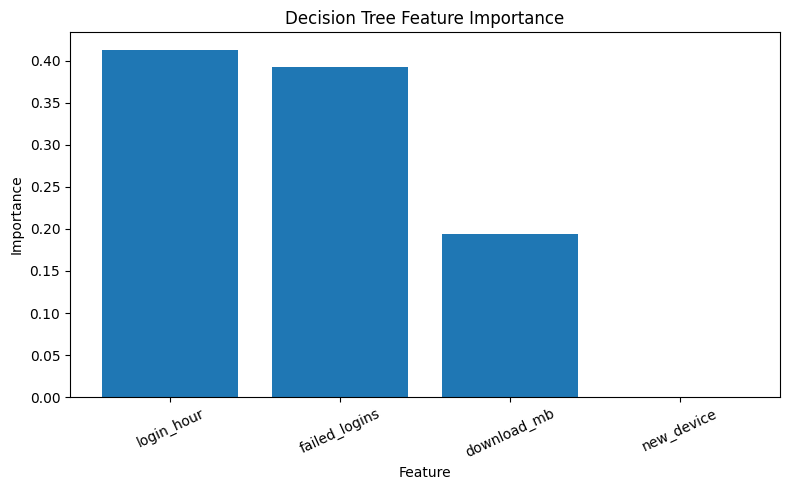

In [10]:
# Feature importance chart
plt.figure(figsize=(8, 5))
plt.bar(
    importance['feature'],
    importance['importance']
)

plt.title('Decision Tree Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [11]:
# Three new login records from the lab manual
new_records = pd.DataFrame([
    {
        'failed_logins': 0,
        'login_hour': 10,
        'new_device': 0,
        'download_mb': 45
    },
    {
        'failed_logins': 8,
        'login_hour': 2,
        'new_device': 1,
        'download_mb': 180
    },
    {
        'failed_logins': 2,
        'login_hour': 23,
        'new_device': 1,
        'download_mb': 900
    }
])

new_records['prediction'] = model.predict(new_records)

display(new_records)


,failed_logins,login_hour,new_device,download_mb,prediction
0,0,10,0,45,Normal
1,8,2,1,180,Suspicious
2,2,23,1,900,Suspicious


### Q5 Interpretation

1. **Record 1:** 0 failed logins, normal daytime hour, known device and low download volume generally provide fewer suspicious indicators.
2. **Record 2:** 8 failed logins, a new device, and a 2 AM login provide several suspicious indicators.
3. **Record 3:** A new device, late-night login and very large download volume provide suspicious-looking indicators.

The exact predictions depend on the supplied dataset and the trained Decision Tree.


## Q6. False Positives, False Negatives and Reflection — 5 Marks

**False positive example:** Legitimate late-night work on a new device is marked **Suspicious**.

**False negative example:** A disguised attack with few obvious indicators is marked **Normal**.

**Dataset limitation:** The dataset is small and contains only four input features, so it cannot represent the full range of real-world login behaviour.

**Human review:** A security analyst should review suspicious or high-impact results before taking important operational action, especially where a false negative could allow an attack to go unnoticed.


In [12]:
# Save the completed result table
df.to_csv('Lab2_Login_ML_Result.csv', index=False)

print('Saved: Lab2_Login_ML_Result.csv')


Saved: Lab2_Login_ML_Result.csv


## Final Lab Summary

### Supervised Learning
The Decision Tree uses labelled login records (`Normal` / `Suspicious`) to learn classification rules and predict the class of unseen records.

### Unsupervised Learning
K-Means does not use the target label during clustering. It groups login records according to similarity in the selected numeric features.

### Model Limitations
- The dataset is small.
- Only four features are used.
- K-Means clusters do not necessarily correspond directly to security labels.
- Feature importance is model-specific and does not prove causation.
- Human review remains important for operational security decisions.

### Files Produced
- `Lab2_Login_ML_Result.csv`
